# Legacy Channel Model vs GeoRules Comparison

This notebook runs the **original legacy** fluvial channel code with its default
parameters and compares the output to the equivalent `georules.MeanderingChannelLayer`.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Add legacy directory to path so it can find genchannel / make_cutoff
legacy_dir = os.path.abspath('../legacy/channel_model')
sys.path.insert(0, legacy_dir)

# Handle numba.jitclass location change in newer versions
try:
    from numba import jitclass
except ImportError:
    from numba.experimental import jitclass
    import numba
    numba.jitclass = jitclass

from fluvial_3d import fluvial as legacy_fluvial
print('Legacy fluvial imported successfully')

Legacy fluvial imported successfully


## 1. Run legacy code with all defaults

Default parameters from the legacy `fluvial` class:
- Grid: nx=256, ny=128, nz=64, cell size 16×16×3
- Channel half-width b=80, depth/width ratio 0.4
- Physics: Cf=0.0009, A=10.0, I=0.008, Q=0.9
- Streamline noise: s=0.8 (hard-coded in `generate_streamline`)
- 10 channel generations (100 migration iterations)

In [2]:
np.random.seed(42)
legacy = legacy_fluvial()  # all defaults
legacy.simulation(nchannel=10)

print(f'Legacy porosity shape: {legacy.poro.shape}')
print(f'Legacy facies shape:   {legacy.facies.shape}')
print(f'Channel fill fraction: {(legacy.facies > 0).mean():.2f}')

Legacy porosity shape: (256, 128, 64)
Legacy facies shape:   (256, 128, 64)
Channel fill fraction: 0.07


## 2. Plot legacy output — Z slices (porosity)

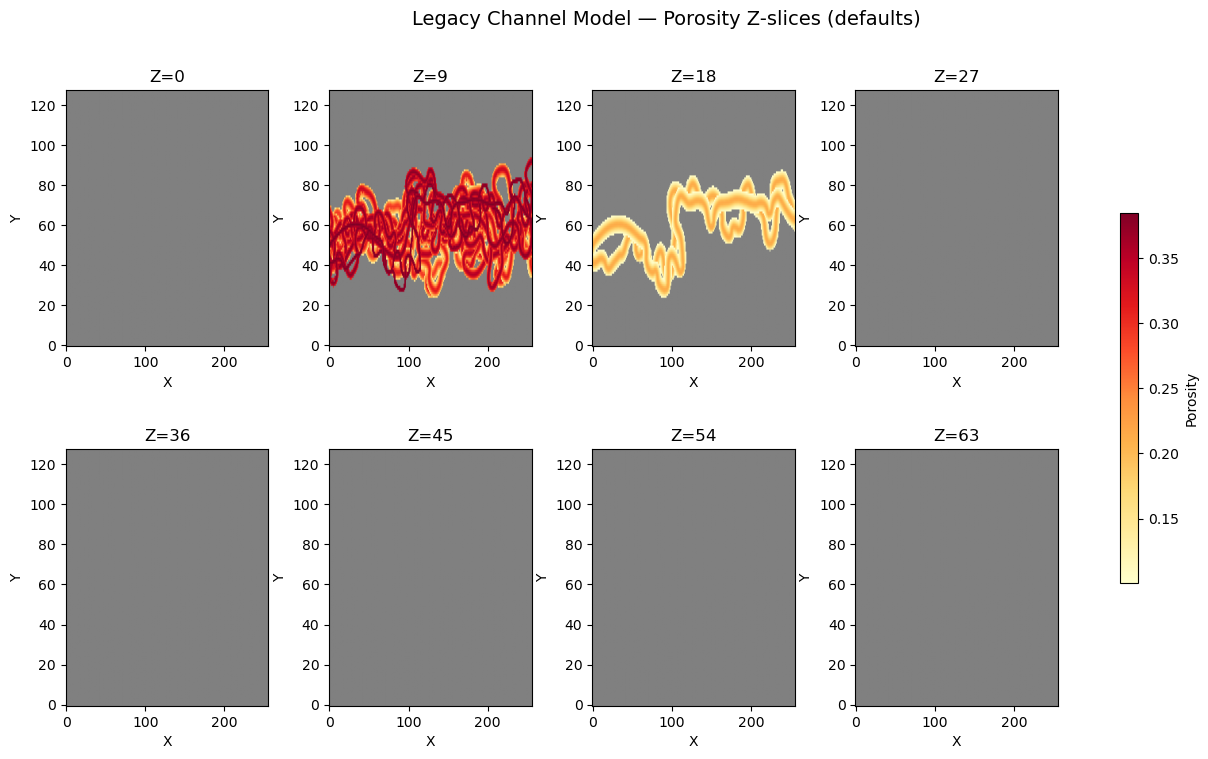

In [3]:
nz_leg = legacy.poro.shape[2]
indices = np.linspace(0, nz_leg - 1, 8, dtype=int)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.subplots_adjust(hspace=0.4, wspace=0.3)
masked = np.where(legacy.poro > 0.05, legacy.poro, np.nan)
vmin = np.nanmin(masked[np.isfinite(masked)])
vmax = np.nanmax(masked[np.isfinite(masked)])

cmap = plt.get_cmap('YlOrRd').copy()
cmap.set_bad(color='grey')

for i, iz in enumerate(indices):
    ax = axes.flat[i]
    im = ax.imshow(masked[:, :, iz].T, origin='lower', cmap=cmap,
                   vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(f'Z={iz}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

fig.colorbar(im, ax=axes, shrink=0.6, label='Porosity')
fig.suptitle('Legacy Channel Model — Porosity Z-slices (defaults)', fontsize=14)
plt.show()

## 3. Plot legacy output — Facies Z slices

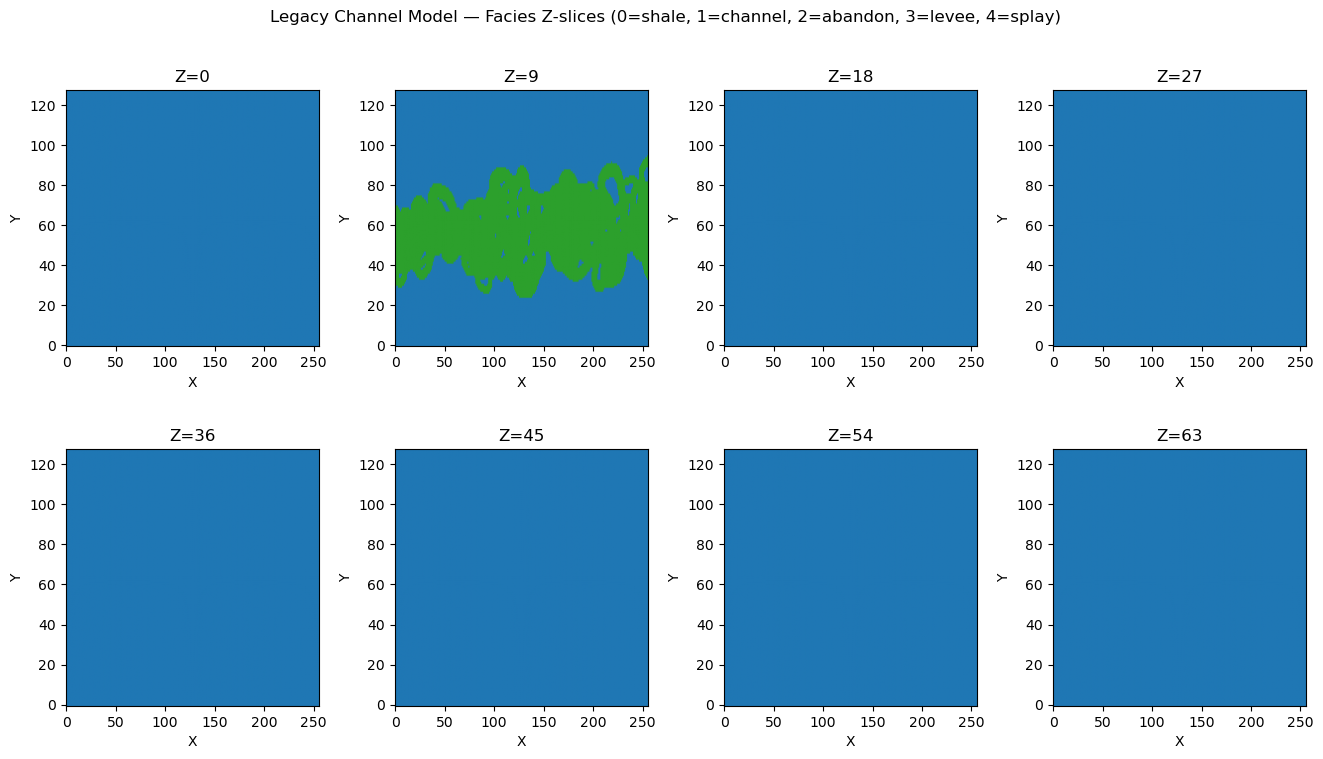

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

for i, iz in enumerate(indices):
    ax = axes.flat[i]
    ax.imshow(legacy.facies[:, :, iz].T, origin='lower', cmap='tab10',
              vmin=0, vmax=4, aspect='auto')
    ax.set_title(f'Z={iz}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

fig.suptitle('Legacy Channel Model — Facies Z-slices (0=shale, 1=channel, 2=abandon, 3=levee, 4=splay)',
             fontsize=12)
plt.show()

## 4. Run GeoRules with equivalent parameters

We match the legacy grid and physics exactly.  Legacy streamline noise
was `s=0.8`; under our quadratic mapping (`s = 0.2 * meander_scale²`),
that corresponds to `meander_scale = 2.0`.

In [ ]:
import georules as gr

np.random.seed(42)
ch = gr.MeanderingChannelLayer(
    nx=256, ny=128, nz=64,
    x_len=256*16, y_len=128*16, z_len=64*3,
    top_depth=5000, dip=0.0,
)
ch.create_geology(
    channel_width=80,        # legacy b=80
    n_channels=10,           # legacy nchannel=10
    depth_width_ratio=0.4,   # legacy dwratio=0.4
    friction_coeff=0.0009,   # legacy Cf
    amplitude=10.0,          # legacy A
    slope=0.008,             # legacy I
    discharge=0.9,           # legacy Q
    meander_scale=2.0,       # maps to s=0.8 (legacy default)
    avulsion_prob=0,         # legacy pavul=0
)
print(f'GeoRules porosity shape: {ch.poro_mat.shape}')
print(f'Channel fill fraction:   {(ch.facies > 0).mean():.2f}')

## 5. Plot GeoRules output — Z slices (porosity)

In [ ]:
gr.plot_slices(ch.poro_mat, axis=2, title='GeoRules Channel — Porosity Z-slices (meander_scale=2.0)')

## 6. Plot GeoRules output — Facies Z slices

In [ ]:
gr.plot_slices(ch.facies.astype(float), axis=2, cmap='tab10', title='GeoRules Channel — Facies Z-slices')

## 7. Side-by-side comparison (single Z slice)

In [ ]:
iz_compare = 20  # pick a slice with channels in both

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

cmap = plt.get_cmap('YlOrRd').copy()
cmap.set_bad(color='grey')

leg_masked = np.where(legacy.poro > 0.05, legacy.poro, np.nan)
gr_masked = np.where(ch.poro_mat > 0, ch.poro_mat, np.nan)

# Use common color range
all_vals = np.concatenate([leg_masked[np.isfinite(leg_masked)],
                           gr_masked[np.isfinite(gr_masked)]])
vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)

ax1.imshow(leg_masked[:, :, iz_compare].T, origin='lower', cmap=cmap,
           vmin=vmin, vmax=vmax, aspect='auto')
ax1.set_title(f'Legacy (s=0.8)  Z={iz_compare}')
ax1.set_xlabel('X'); ax1.set_ylabel('Y')

im = ax2.imshow(gr_masked[:, :, iz_compare].T, origin='lower', cmap=cmap,
                vmin=vmin, vmax=vmax, aspect='auto')
ax2.set_title(f'GeoRules (meander_scale=2.0)  Z={iz_compare}')
ax2.set_xlabel('X'); ax2.set_ylabel('Y')

fig.colorbar(im, ax=[ax1, ax2], shrink=0.7, label='Porosity')
fig.suptitle('Legacy vs GeoRules — Same grid, same physics', fontsize=14)
plt.show()

## 8. Cube views

In [ ]:
gr.plot_cube_slices(ch.poro_mat, title='GeoRules Channel — Cube View (meander_scale=2.0)')